<h1 style="color:#56B4E9;">Week 8 — Day 4</h1>

<h2 style="color:#0072B2;">Model Integration & Error Analysis</h2>

### Oxford-IIIT Pet — 37-Breed Classification

Day 4 continues directly from the OpenCV and MobileNetV2 preprocessing work completed on Day 3. The goal is to move from separate experimental cells toward one consistent image-classification system.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Connect preprocessing and a trained model in one prediction pipeline.
- Guarantee that training-time and prediction-time preprocessing are identical.
- Train a custom classifier for the 37 Oxford-IIIT Pet breeds.
- Evaluate the model using a confusion matrix.
- Inspect misclassified images and identify repeated error patterns.
- Save the integrated model and its class names for later web inference.

<h2 style="color:#0072B2;">4.1 From Preprocessing to Integration</h2>

Day 3 verified that OpenCV images can be converted from BGR to RGB, resized without distortion, and transformed to the range expected by MobileNetV2. However, the ImageNet classifier used there predicts 1,000 ImageNet categories, not the 37 Oxford Pet breeds.

Therefore, Day 4 will keep the pretrained MobileNetV2 feature extractor and later attach a new classifier trained specifically on the pet-breed labels.

The final contract will be:

$$
	ext{Raw image}
\rightarrow 	ext{OpenCV read}
\rightarrow 	ext{BGR to RGB}
\rightarrow 	ext{resize with padding}
\rightarrow 	ext{MobileNetV2 preprocessing}
\rightarrow 	ext{breed probabilities}
$$

> The same ordered steps must be used during both training and prediction.

In [1]:
%pip install -q opencv-python scikit-learn seaborn

from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import get_file

RANDOM_STATE = 42
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("Target size:", TARGET_SIZE)

Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1788970608.830958  244423 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788970608.834673  244423 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788970609.339239  244423 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788970611.027378  244423 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
OpenCV version: 5.0.0
Target size: (224, 224)


<h3 style="color:#009E73;">Reusing the Day 3 Dataset</h3>

The next cell first searches the Day 3 data directory. The large archive is downloaded only when the extracted JPG files are not already available.

In [2]:
DATA_DIRECTORY = Path(
    "../day3/data/oxford_iiit_pet"
).resolve()

image_paths = (
    sorted(DATA_DIRECTORY.rglob("*.jpg"))
    if DATA_DIRECTORY.exists()
    else []
)

if not image_paths:
    archive_path = Path(
        get_file(
            fname="images.tar.gz",
            origin=(
                "https://www.robots.ox.ac.uk/~vgg/"
                "data/pets/data/images.tar.gz"
            ),
            extract=True,
            cache_dir=str(DATA_DIRECTORY.parent),
            cache_subdir=DATA_DIRECTORY.name,
        )
    )

    search_root = (
        archive_path
        if archive_path.is_dir()
        else archive_path.parent
    )
    image_paths = sorted(search_root.rglob("*.jpg"))

assert image_paths, (
    f"No JPG images were found under {DATA_DIRECTORY}"
)

IMAGE_DIRECTORY = image_paths[0].parent

print("Image directory:", IMAGE_DIRECTORY)
print("Number of image files:", len(image_paths))

Image directory: /tmp/.keras/oxford_iiit_pet/images_extracted/images
Number of image files: 7390


<h2 style="color:#0072B2;">4.2 Labels and Evaluation Splits</h2>

Each filename contains the breed followed by an image number. For example, `american_bulldog_12.jpg` belongs to the `american_bulldog` class.

We create the labels before splitting and use stratification so every breed keeps approximately the same proportion in training, validation, and test data. The test split remains untouched until final evaluation.

In [3]:
image_metadata = pd.DataFrame({
    "image_path": [str(path) for path in image_paths],
    "filename": [path.name for path in image_paths],
    "breed": [
        path.stem.rsplit("_", 1)[0]
        for path in image_paths
    ],
})

class_names = sorted(image_metadata["breed"].unique())
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}
image_metadata["label"] = image_metadata["breed"].map(
    class_to_index
)

assert len(class_names) == 37
assert image_metadata["label"].notna().all()
assert image_metadata["image_path"].is_unique

display(image_metadata.head())
print("Images:", len(image_metadata))
print("Breed classes:", len(class_names))
print("Smallest class:", image_metadata["breed"].value_counts().min())
print("Largest class:", image_metadata["breed"].value_counts().max())

,image_path,filename,breed,label
0,/tmp/.keras/oxford_iiit_pet/images_extracted/i...,Abyssinian_1.jpg,Abyssinian,0
1,/tmp/.keras/oxford_iiit_pet/images_extracted/i...,Abyssinian_10.jpg,Abyssinian,0
2,/tmp/.keras/oxford_iiit_pet/images_extracted/i...,Abyssinian_100.jpg,Abyssinian,0
3,/tmp/.keras/oxford_iiit_pet/images_extracted/i...,Abyssinian_101.jpg,Abyssinian,0
4,/tmp/.keras/oxford_iiit_pet/images_extracted/i...,Abyssinian_102.jpg,Abyssinian,0


Images: 7390
Breed classes: 37
Smallest class: 191
Largest class: 200


In [4]:
train_metadata, temporary_metadata = train_test_split(
    image_metadata,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=image_metadata["label"],
)

validation_metadata, test_metadata = train_test_split(
    temporary_metadata,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temporary_metadata["label"],
)

train_metadata = train_metadata.reset_index(drop=True)
validation_metadata = validation_metadata.reset_index(drop=True)
test_metadata = test_metadata.reset_index(drop=True)

split_summary = pd.DataFrame([
    {"Split": "Training", "Images": len(train_metadata)},
    {"Split": "Validation", "Images": len(validation_metadata)},
    {"Split": "Test", "Images": len(test_metadata)},
])

train_paths = set(train_metadata["image_path"])
validation_paths = set(validation_metadata["image_path"])
test_paths = set(test_metadata["image_path"])

assert train_paths.isdisjoint(validation_paths)
assert train_paths.isdisjoint(test_paths)
assert validation_paths.isdisjoint(test_paths)
assert len(train_paths | validation_paths | test_paths) == len(image_metadata)
assert train_metadata["breed"].nunique() == 37
assert validation_metadata["breed"].nunique() == 37
assert test_metadata["breed"].nunique() == 37

display(split_summary)
print("No image leakage between splits.")

,Split,Images
0,Training,5173
1,Validation,1108
2,Test,1109


No image leakage between splits.


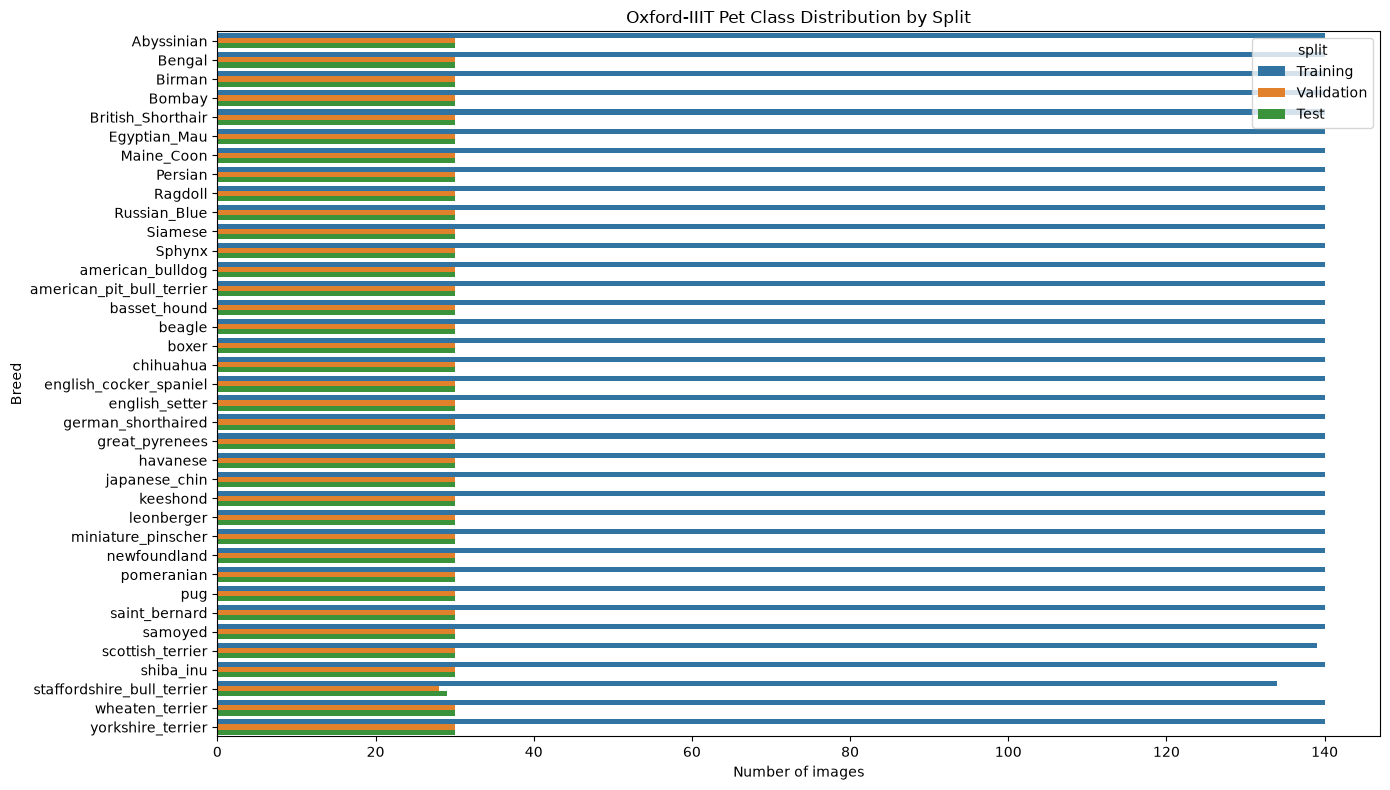

In [5]:
split_distribution = pd.concat([
    train_metadata.assign(split="Training"),
    validation_metadata.assign(split="Validation"),
    test_metadata.assign(split="Test"),
])[["breed", "split"]]

plt.figure(figsize=(14, 8))
sns.countplot(
    data=split_distribution,
    y="breed",
    hue="split",
    order=class_names,
)
plt.title("Oxford-IIIT Pet Class Distribution by Split")
plt.xlabel("Number of images")
plt.ylabel("Breed")
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">4.3 The Preprocessing Contract</h2>

Training/serving skew occurs when the model receives data differently during prediction than it did during training. A color-order mismatch or a second normalization step can silently damage the result.

For MobileNetV2, the final pixel transformation is:

$$
x_{model} = \frac{x_{RGB}}{127.5} - 1
$$

The reusable function below is the only approved preprocessing path for both training and future `predict_pet_image()` inference.

In [6]:
def resize_with_padding(
    image,
    target_size=(224, 224),
    padding_color=(0, 0, 0),
):
    target_width, target_height = target_size
    original_height, original_width = image.shape[:2]

    scale = min(
        target_width / original_width,
        target_height / original_height,
    )
    new_width = int(round(original_width * scale))
    new_height = int(round(original_height * scale))

    interpolation = (
        cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    )
    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=interpolation,
    )

    remaining_width = target_width - new_width
    remaining_height = target_height - new_height
    left = remaining_width // 2
    right = remaining_width - left
    top = remaining_height // 2
    bottom = remaining_height - top

    return cv2.copyMakeBorder(
        resized,
        top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=padding_color,
    )


def preprocess_pet_image(
    image_path,
    target_size=TARGET_SIZE,
):
    bgr_image = cv2.imread(str(image_path))

    if bgr_image is None:
        raise ValueError(
            f"OpenCV could not read: {image_path}"
        )

    rgb_image = cv2.cvtColor(
        bgr_image,
        cv2.COLOR_BGR2RGB,
    )
    padded_image = resize_with_padding(
        rgb_image,
        target_size=target_size,
    )
    model_input = preprocess_input(
        padded_image.astype(np.float32)
    )

    return model_input

Preprocessing contract passed.
Shape: (224, 224, 3)
Data type: float32
Minimum: -1.0
Maximum: 0.9843
Sample breed: japanese_chin


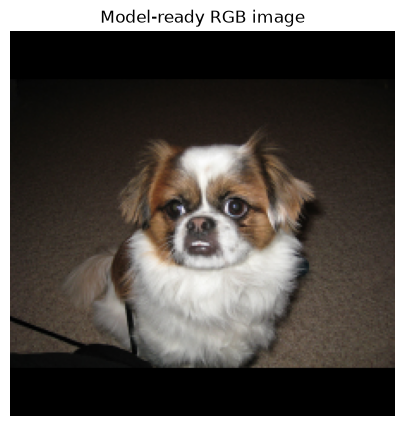

In [7]:
sample_path = train_metadata.loc[0, "image_path"]
sample_model_input = preprocess_pet_image(sample_path)

assert sample_model_input.shape == (224, 224, 3)
assert sample_model_input.dtype == np.float32
assert sample_model_input.min() >= -1.0
assert sample_model_input.max() <= 1.0

print("Preprocessing contract passed.")
print("Shape:", sample_model_input.shape)
print("Data type:", sample_model_input.dtype)
print("Minimum:", round(float(sample_model_input.min()), 4))
print("Maximum:", round(float(sample_model_input.max()), 4))
print("Sample breed:", train_metadata.loc[0, "breed"])

plt.figure(figsize=(5, 5))
plt.imshow((sample_model_input + 1.0) / 2.0)
plt.title("Model-ready RGB image")
plt.axis("off")
plt.show()

<h2 style="color:#0072B2;">Part 1 Checkpoint</h2>

At this point we have not trained the classifier yet. We have established the foundations required for a trustworthy experiment:

- The Day 3 dataset was reused without an unnecessary download.
- All 37 breed labels were reconstructed from the filenames.
- Stratified training, validation, and test splits were created.
- Leakage between the three splits was ruled out.
- One preprocessing function now defines the exact MobileNetV2 input contract.

The next part will create efficient datasets and train the custom classification head.

<h2 style="color:#0072B2;">4.4 Building the TensorFlow Data Pipeline</h2>

The image paths and labels are now converted into efficient TensorFlow datasets.

The same `preprocess_pet_image()` function is used for every split. This guarantees that the model receives identical color conversion, resizing, padding, and MobileNetV2 normalization during training, validation, testing, and future prediction.

Data augmentation will be placed inside the model and activated only during training.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image_with_opencv(path_value, label_value):
    raw_path = (
        path_value.item()
        if hasattr(path_value, "item")
        else path_value
    )

    if isinstance(raw_path, bytes):
        raw_path = raw_path.decode("utf-8")

    image = preprocess_pet_image(raw_path)

    return image, np.int32(label_value)


def tensorflow_preprocessing(image_path, label):
    image, label = tf.numpy_function(
        load_image_with_opencv,
        [image_path, label],
        [tf.float32, tf.int32],
    )

    image.set_shape((224, 224, 3))
    label.set_shape(())

    return image, label


def create_image_dataset(metadata, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        metadata["image_path"].to_numpy(),
        metadata["label"].to_numpy(dtype=np.int32),
    ))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(metadata),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        tensorflow_preprocessing,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training,
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_image_dataset(
    train_metadata,
    training=True,
)

validation_dataset = create_image_dataset(
    validation_metadata,
)

test_dataset = create_image_dataset(
    test_metadata,
)

print("Training batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Test batches:", len(test_dataset))

E0000 00:00:1788972320.528604  244423 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training batches: 162
Validation batches: 35
Test batches: 35


In [9]:
sample_images, sample_labels = next(
    iter(train_dataset)
)

assert sample_images.shape[1:] == (224, 224, 3)
assert sample_images.dtype == tf.float32
assert sample_labels.dtype == tf.int32
assert tf.reduce_min(sample_images) >= -1.0
assert tf.reduce_max(sample_images) <= 1.0

print("Batch shape:", sample_images.shape)
print("Labels shape:", sample_labels.shape)
print("Pixel range:", (
    round(float(tf.reduce_min(sample_images)), 4),
    round(float(tf.reduce_max(sample_images)), 4),
))
print("First five labels:", sample_labels[:5].numpy())

Batch shape: (32, 224, 224, 3)
Labels shape: (32,)
Pixel range: (-1.0, 1.0)
First five labels: [33 11 14 17 18]


<h2 style="color:#0072B2;">4.5 Building the Transfer-Learning Model</h2>

MobileNetV2 already learned general visual features from ImageNet. Its convolutional base will initially remain frozen, while a new classification head learns the 37 Oxford Pet breeds.

The final layer uses Softmax:

$$
P(y=k \mid x)=\frac{e^{z_k}}{\sum_{j=1}^{37}e^{z_j}}
$$

The output contains 37 probabilities whose sum equals one.

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
], name="training_augmentation")


mobilenet_base = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

mobilenet_base.trainable = False


model_inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="model_ready_image",
)

x = data_augmentation(model_inputs)
x = mobilenet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

model_outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax",
    name="breed_probabilities",
)(x)

pet_breed_model = tf.keras.Model(
    model_inputs,
    model_outputs,
    name="oxford_pet_mobilenetv2",
)

pet_breed_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=3,
            name="top_3_accuracy",
        ),
    ],
)

pet_breed_model.summary()

Model: "oxford_pet_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ model_ready_image (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ breed_probabilities (Dense)     │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

<h2 style="color:#0072B2;">4.6 Verifying the Model Before Training</h2>

Before training, we pass a small image batch through the complete model.

For every image, the final layer produces 37 probabilities:

$$
P(y=k \mid x)=\frac{e^{z_k}}{\sum_{j=1}^{37} e^{z_j}}
$$

Because Softmax is used, the probabilities for each image must sum to approximately 1.

This confirms that the complete pipeline produces valid classification outputs.

In [11]:
sanity_probabilities = pet_breed_model.predict(
    sample_images[:4],
    verbose=0,
)

assert sanity_probabilities.shape == (4, len(class_names))
assert np.allclose(
    sanity_probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)

print("Prediction shape:", sanity_probabilities.shape)
print(
    "Probability sums:",
    np.round(sanity_probabilities.sum(axis=1), 5),
)
print(
    "Initial predicted labels:",
    np.argmax(sanity_probabilities, axis=1),
)
print("Model output check passed.")

Prediction shape: (4, 37)
Probability sums: [1. 1. 1. 1.]
Initial predicted labels: [36 36 29 36]
Model output check passed.


<h2 style="color:#0072B2;">4.7 Training the Classification Head</h2>

During this stage, the MobileNetV2 convolutional base remains frozen.

Only the new classification head learns how to connect the extracted visual features
to the 37 Oxford-IIIT Pet breeds.

The loss function is sparse categorical cross-entropy:

$$
L=-\frac{1}{N}\sum_{i=1}^{N}\log P(y_i \mid x_i)
$$

The callbacks save the best model, reduce the learning rate when progress slows,
and stop training before unnecessary overfitting.

In [12]:
DAY4_OUTPUT_DIRECTORY = Path("outputs/week8_day4")
DAY4_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = str(
    DAY4_OUTPUT_DIRECTORY / "best_pet_breed_model.keras"
)

training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1,
    ),
]

print("Best model will be saved to:")
print(BEST_MODEL_PATH)

Best model will be saved to:
outputs/week8_day4/best_pet_breed_model.keras


In [13]:
INITIAL_EPOCHS = 8

training_history = pet_breed_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=training_callbacks,
)

Epoch 1/8


/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 55/162 ━━━━━━━━━━━━━━━━━━━━ 51s 484ms/step - accuracy: 0.4085 - loss: 2.2754 - top_3_accuracy: 0.6045

Corrupt JPEG data: premature end of data segment


117/162 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step - accuracy: 0.5970 - loss: 1.5352 - top_3_accuracy: 0.7748

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9200 - loss: 0.2465 - top_3_accuracy: 0.9921
Epoch 7: val_loss did not improve from 0.29802

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
162/162 ━━━━━━━━━━━━━━━━━━━━ 90s 556ms/step - accuracy: 0.9200 - loss: 0.2465 - top_3_accuracy: 0.9921 - val_accuracy: 0.9025 - val_loss: 0.3128 - val_top_3_accuracy: 0.9810 - learning_rate: 0.0010
Epoch 8/8
 71/162 ━━━━━━━━━━━━━━━━━━━━ 42s 467ms/step - accuracy: 0.9393 - loss: 0.1916 - top_3_accuracy: 0.9974

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


124/162 ━━━━━━━━━━━━━━━━━━━━ 17s 470ms/step - accuracy: 0.9355 - loss: 0.1944 - top_3_accuracy: 0.9975

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9337 - loss: 0.2009 - top_3_accuracy: 0.9961
Epoch 8: val_loss did not improve from 0.29802

Epoch 8: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
162/162 ━━━━━━━━━━━━━━━━━━━━ 91s 562ms/step - accuracy: 0.9337 - loss: 0.2009 - top_3_accuracy: 0.9961 - val_accuracy: 0.9125 - val_loss: 0.3017 - val_top_3_accuracy: 0.9829 - learning_rate: 3.0000e-04
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 6.


<h2 style="color:#0072B2;">4.8 Training Behavior</h2>

The classifier improved from approximately 65% training accuracy in the first epoch
to more than 90%.

The validation loss reached its best value at epoch 6. After that, the training
accuracy continued improving while the validation loss stopped improving.

This small generalization gap indicates the beginning of overfitting.
Early stopping restored the weights from the best epoch.

In [14]:
history_table = pd.DataFrame(
    training_history.history
)

history_table.index = np.arange(
    1,
    len(history_table) + 1,
)
history_table.index.name = "epoch"

best_epoch = history_table["val_loss"].idxmin()
best_epoch_results = history_table.loc[best_epoch]

display(history_table.round(4))

print("Best epoch:", best_epoch)
print(
    "Best validation loss:",
    round(best_epoch_results["val_loss"], 4),
)
print(
    "Validation accuracy at best epoch:",
    round(best_epoch_results["val_accuracy"], 4),
)

history_table.to_csv(
    DAY4_OUTPUT_DIRECTORY / "training_history.csv"
)

,accuracy,loss,top_3_accuracy,val_accuracy,val_loss,val_top_3_accuracy,learning_rate
epoch,,,,,,,
1,0.6520,1.3067,0.8254,0.8556,0.4763,0.9774,0.0010
2,0.8448,0.5038,0.9708,0.8899,0.3555,0.9819,0.0010
3,0.8749,0.3890,0.9805,0.8998,0.3358,0.9847,0.0010
4,0.8933,0.3379,0.9855,0.8908,0.3244,0.9874,0.0010
5,0.9008,0.2969,0.9880,0.8935,0.3120,0.9838,0.0010
6,0.9095,0.2750,0.9907,0.9007,0.2980,0.9838,0.0010
7,0.9200,0.2465,0.9921,0.9025,0.3128,0.9810,0.0010
8,0.9337,0.2009,0.9961,0.9125,0.3017,0.9829,0.0003


Best epoch: 6
Best validation loss: 0.298
Validation accuracy at best epoch: 0.9007


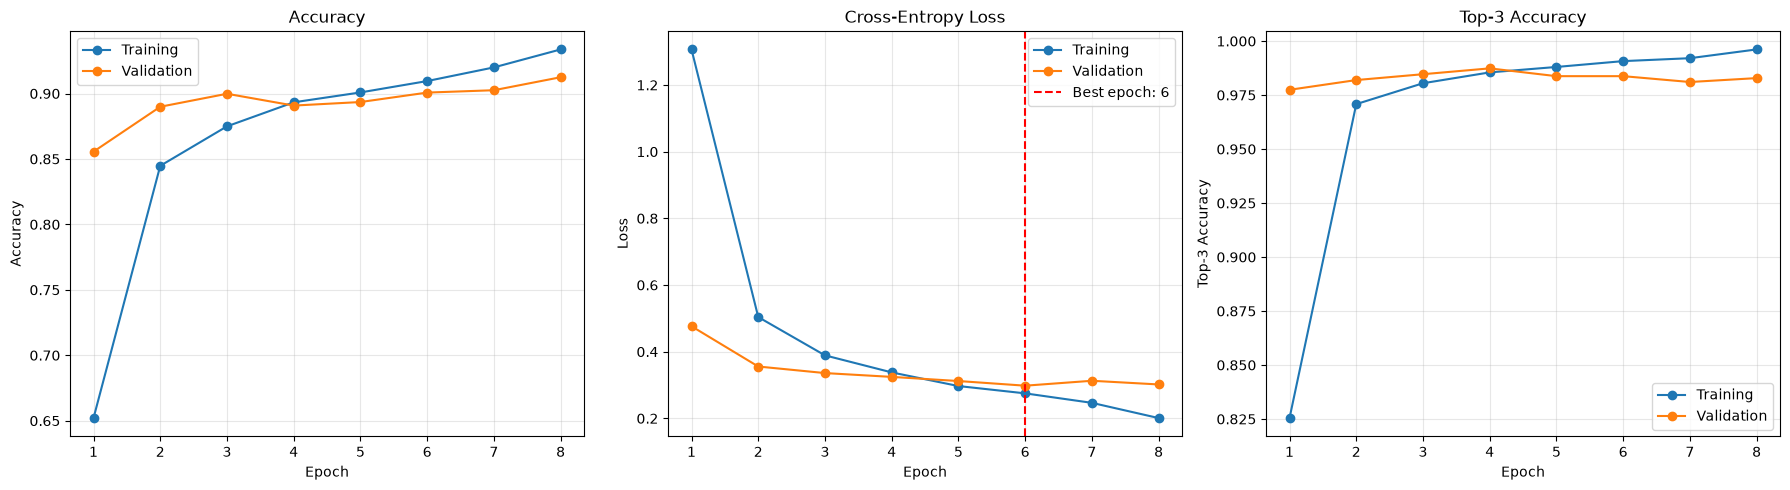

In [15]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

epochs = history_table.index

axes[0].plot(
    epochs,
    history_table["accuracy"],
    marker="o",
    label="Training",
)
axes[0].plot(
    epochs,
    history_table["val_accuracy"],
    marker="o",
    label="Validation",
)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    history_table["loss"],
    marker="o",
    label="Training",
)
axes[1].plot(
    epochs,
    history_table["val_loss"],
    marker="o",
    label="Validation",
)
axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)
axes[1].set_title("Cross-Entropy Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(
    epochs,
    history_table["top_3_accuracy"],
    marker="o",
    label="Training",
)
axes[2].plot(
    epochs,
    history_table["val_top_3_accuracy"],
    marker="o",
    label="Validation",
)
axes[2].set_title("Top-3 Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Top-3 Accuracy")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    DAY4_OUTPUT_DIRECTORY / "training_curves.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

<h2 style="color:#0072B2;">4.9 Restoring and Evaluating the Best Model</h2>

The checkpoint with the lowest validation loss is restored before final evaluation.

Validation data was used to monitor model development. The test set remained unseen
and is now evaluated once to estimate performance on new images.

Top-1 accuracy requires the correct breed to receive the highest probability.
Top-3 accuracy considers the prediction successful when the correct breed appears
among the three highest probabilities.

In [16]:
best_pet_breed_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

validation_results = best_pet_breed_model.evaluate(
    validation_dataset,
    verbose=0,
    return_dict=True,
)

test_results = best_pet_breed_model.evaluate(
    test_dataset,
    verbose=0,
    return_dict=True,
)

evaluation_table = pd.DataFrame([
    {
        "split": "Validation",
        **validation_results,
    },
    {
        "split": "Test",
        **test_results,
    },
])

display(evaluation_table.round(4))

evaluation_table.to_csv(
    DAY4_OUTPUT_DIRECTORY / "final_evaluation.csv",
    index=False,
)

,split,accuracy,loss,top_3_accuracy
0,Validation,0.9007,0.2980,0.9838
1,Test,0.8900,0.3283,0.9838


<h2 style="color:#0072B2;">4.10 Confusion Matrix and Per-Class Analysis</h2>

Accuracy alone does not explain which breeds the model confuses.

For a confusion matrix, each element is:

$$
C_{ij} =
\text{number of images from class } i
\text{ predicted as class } j
$$

Values on the diagonal represent correct predictions. Off-diagonal values represent
errors between breeds.

The normalized confusion matrix divides every row by the number of true examples
in that class, making comparisons fair across classes.

In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

test_probabilities = best_pet_breed_model.predict(
    test_dataset,
    verbose=1,
)

true_labels = test_metadata[
    "label"
].to_numpy(dtype=np.int32)

predicted_labels = np.argmax(
    test_probabilities,
    axis=1,
)

assert len(predicted_labels) == len(test_metadata)
assert test_probabilities.shape == (
    len(test_metadata),
    len(class_names),
)

classification_results = classification_report(
    true_labels,
    predicted_labels,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

classification_table = (
    pd.DataFrame(classification_results)
    .transpose()
)

display(classification_table.round(4))

classification_table.to_csv(
    DAY4_OUTPUT_DIRECTORY /
    "classification_report.csv"
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 990ms/step


,precision,recall,f1-score,support
Abyssinian,0.9615,0.8333,0.8929,30.00
Bengal,1.0000,0.5667,0.7234,30.00
Birman,0.8125,0.8667,0.8387,30.00
Bombay,0.8438,0.9000,0.8710,30.00
British_Shorthair,0.7742,0.8000,0.7869,30.00
Egyptian_Mau,0.6923,0.9000,0.7826,30.00
Maine_Coon,0.9333,0.9333,0.9333,30.00
Persian,1.0000,0.8667,0.9286,30.00
Ragdoll,0.6765,0.7667,0.7188,30.00
Russian_Blue,0.7353,0.8333,0.7812,30.00


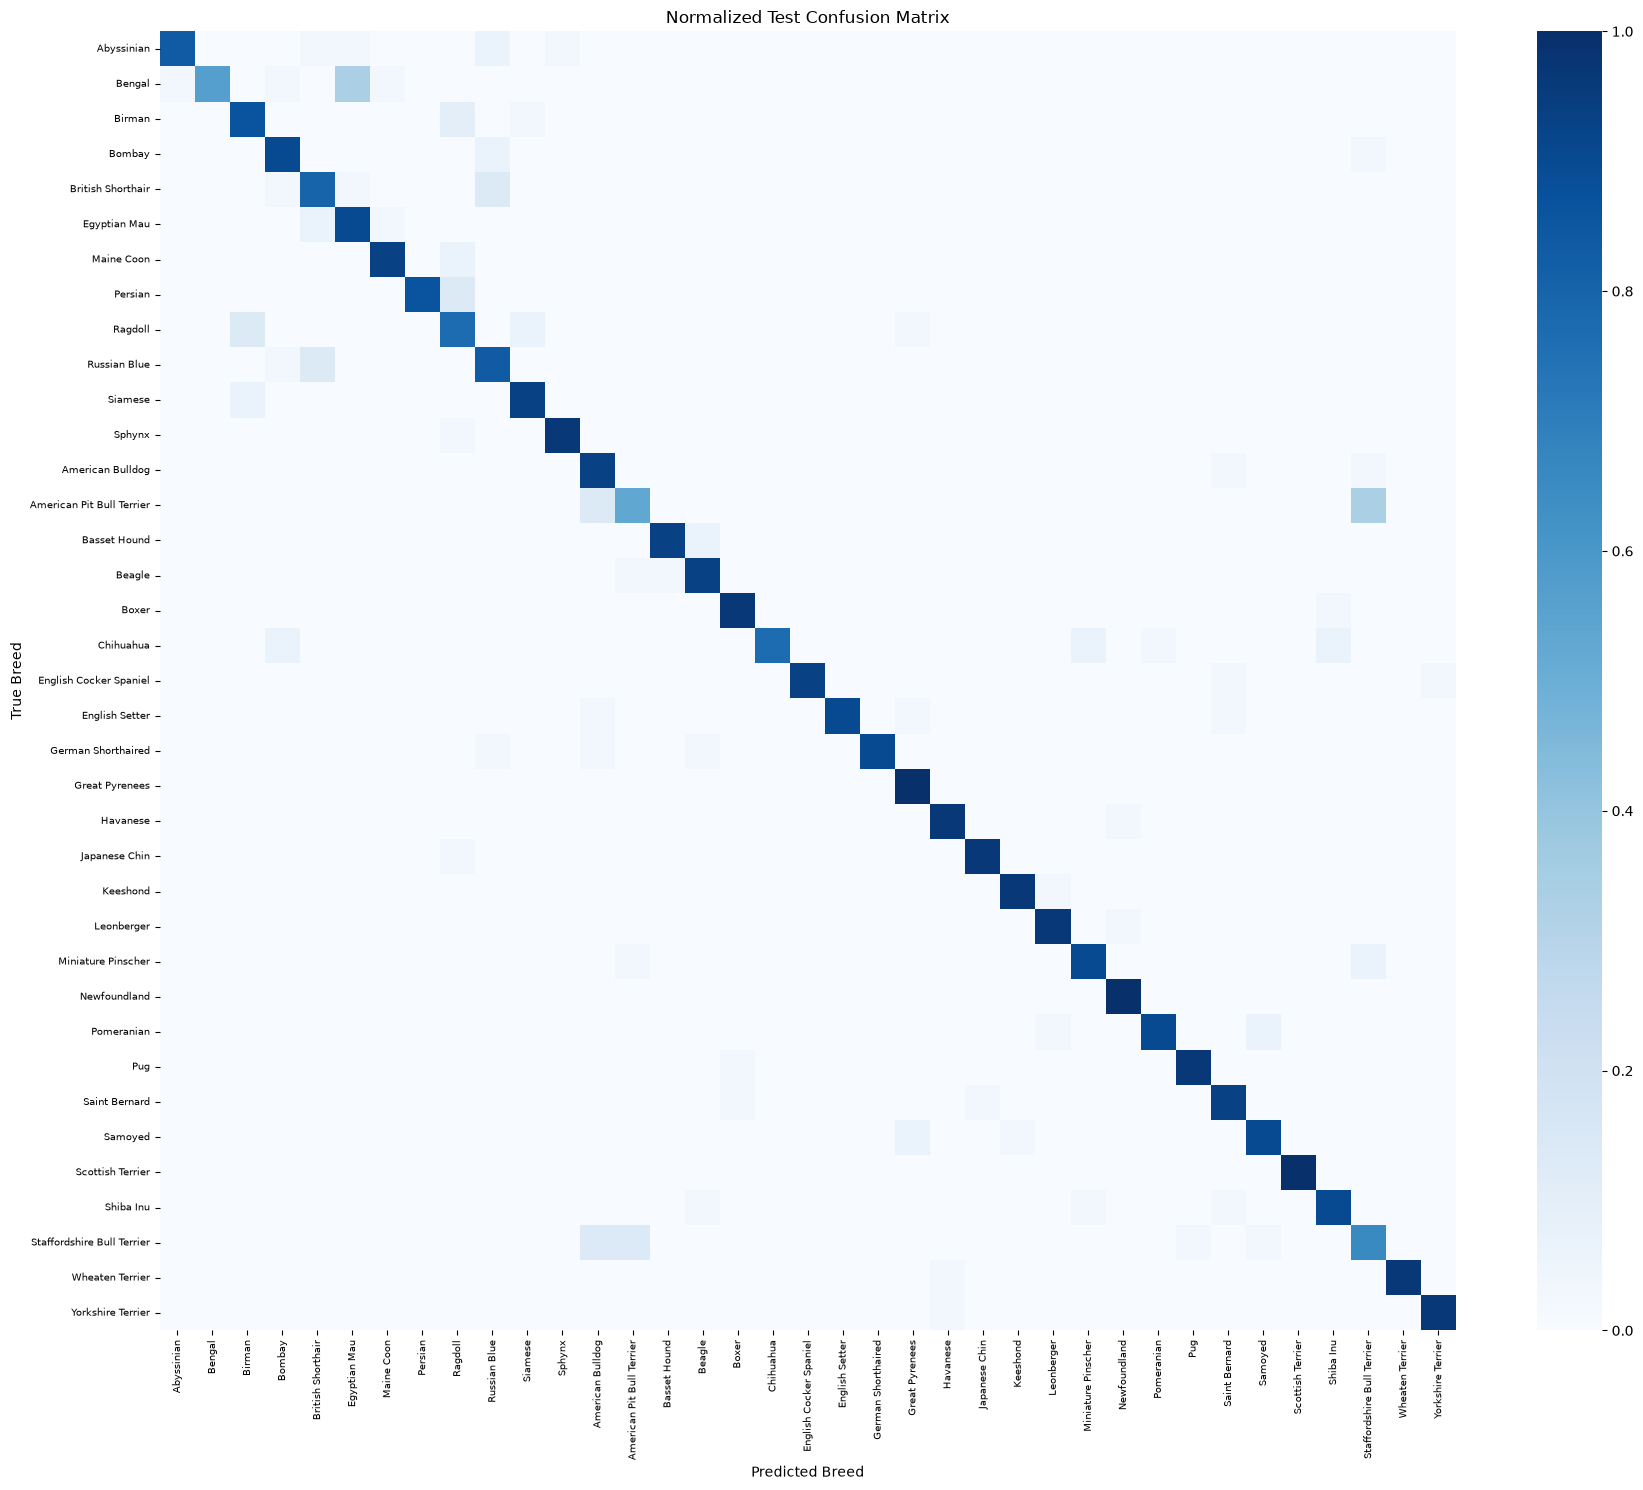

In [26]:
confusion_counts = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(len(class_names)),
)

confusion_normalized = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(len(class_names)),
    normalize="true",
)

display_names = [
    name.replace("_", " ").title()
    for name in class_names
]

plt.figure(figsize=(18, 15))

sns.heatmap(
    confusion_normalized,
    cmap="Blues",
    xticklabels=display_names,
    yticklabels=display_names,
    vmin=0,
    vmax=1,
)

plt.title("Normalized Test Confusion Matrix")
plt.xlabel("Predicted Breed")
plt.ylabel("True Breed")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

plt.savefig(
    DAY4_OUTPUT_DIRECTORY /
    "normalized_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [27]:
off_diagonal_confusion = confusion_counts.copy()
np.fill_diagonal(off_diagonal_confusion, 0)

sorted_positions = np.argsort(
    off_diagonal_confusion.ravel()
)[::-1]

confusion_pairs = []

for flat_position in sorted_positions:
    true_index, predicted_index = np.unravel_index(
        flat_position,
        off_diagonal_confusion.shape,
    )

    error_count = off_diagonal_confusion[
        true_index,
        predicted_index,
    ]

    if error_count == 0:
        break

    confusion_pairs.append({
        "true_breed": display_names[true_index],
        "predicted_breed": display_names[predicted_index],
        "error_count": int(error_count),
        "class_error_percentage": round(
            100 * error_count /
            confusion_counts[true_index].sum(),
            2,
        ),
    })

    if len(confusion_pairs) == 10:
        break

top_confusion_pairs = pd.DataFrame(confusion_pairs)

display(top_confusion_pairs)

top_confusion_pairs.to_csv(
    DAY4_OUTPUT_DIRECTORY /
    "top_confusion_pairs.csv",
    index=False,
)

,true_breed,predicted_breed,error_count,class_error_percentage
0,Bengal,Egyptian Mau,10,33.33
1,American Pit Bull Terrier,Staffordshire Bull Terrier,10,33.33
2,Ragdoll,Birman,4,13.33
3,American Pit Bull Terrier,American Bulldog,4,13.33
4,Staffordshire Bull Terrier,American Pit Bull Terrier,4,13.79
5,Staffordshire Bull Terrier,American Bulldog,4,13.79
6,Russian Blue,British Shorthair,4,13.33
7,British Shorthair,Russian Blue,4,13.33
8,Persian,Ragdoll,4,13.33
9,Birman,Ragdoll,3,10.00


<h2 style="color:#0072B2;">4.11 Inspecting Misclassified Examples</h2>

The confusion matrix shows the general pattern, but individual images explain why
an error happened.

For every test image, we store:

- The true breed.
- The predicted breed.
- Prediction confidence.
- Probability assigned to the correct breed.
- The margin between the predicted and correct probabilities.

A confident wrong prediction usually indicates a model weakness or strong visual
similarity between breeds. A blurry, dark, cropped, or ambiguous image may indicate
a data-quality issue.

In [20]:
test_analysis = test_metadata.copy()

test_analysis["true_breed"] = [
    class_names[index]
    for index in true_labels
]

test_analysis["predicted_label"] = (
    predicted_labels
)

test_analysis["predicted_breed"] = [
    class_names[index]
    for index in predicted_labels
]

test_analysis["confidence"] = np.max(
    test_probabilities,
    axis=1,
)

test_analysis["true_class_probability"] = (
    test_probabilities[
        np.arange(len(true_labels)),
        true_labels,
    ]
)

test_analysis["probability_margin"] = (
    test_analysis["confidence"]
    - test_analysis["true_class_probability"]
)

test_analysis["correct"] = (
    true_labels == predicted_labels
)

misclassified_examples = (
    test_analysis[
        ~test_analysis["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Correct predictions:",
    int(test_analysis["correct"].sum()),
)
print(
    "Misclassified images:",
    len(misclassified_examples),
)
print(
    "Test error rate:",
    round(
        100 * len(misclassified_examples)
        / len(test_analysis),
        2,
    ),
    "%",
)

display(
    misclassified_examples[
        [
            "filename",
            "true_breed",
            "predicted_breed",
            "confidence",
            "true_class_probability",
            "probability_margin",
        ]
    ].head(10).round(4)
)

misclassified_examples.to_csv(
    DAY4_OUTPUT_DIRECTORY /
    "misclassified_examples.csv",
    index=False,
)

Correct predictions: 987
Misclassified images: 122
Test error rate: 11.0 %


,filename,true_breed,predicted_breed,confidence,true_class_probability,probability_margin
0,havanese_170.jpg,havanese,newfoundland,0.9905,0.0024,0.9881
1,keeshond_130.jpg,keeshond,leonberger,0.9817,0.0122,0.9695
2,chihuahua_21.jpg,chihuahua,shiba_inu,0.9770,0.0164,0.9606
3,basset_hound_68.jpg,basset_hound,beagle,0.9708,0.0287,0.9422
4,saint_bernard_148.jpg,saint_bernard,boxer,0.9619,0.0094,0.9526
5,Bengal_161.jpg,Bengal,Egyptian_Mau,0.9599,0.0379,0.9219
6,Russian_Blue_150.jpg,Russian_Blue,British_Shorthair,0.9590,0.0364,0.9226
7,Bengal_18.jpg,Bengal,Maine_Coon,0.9330,0.0644,0.8686
8,american_pit_bull_terrier_191.jpg,american_pit_bull_terrier,staffordshire_bull_terrier,0.9317,0.0199,0.9118
9,staffordshire_bull_terrier_45.jpg,staffordshire_bull_terrier,american_pit_bull_terrier,0.9245,0.0072,0.9173


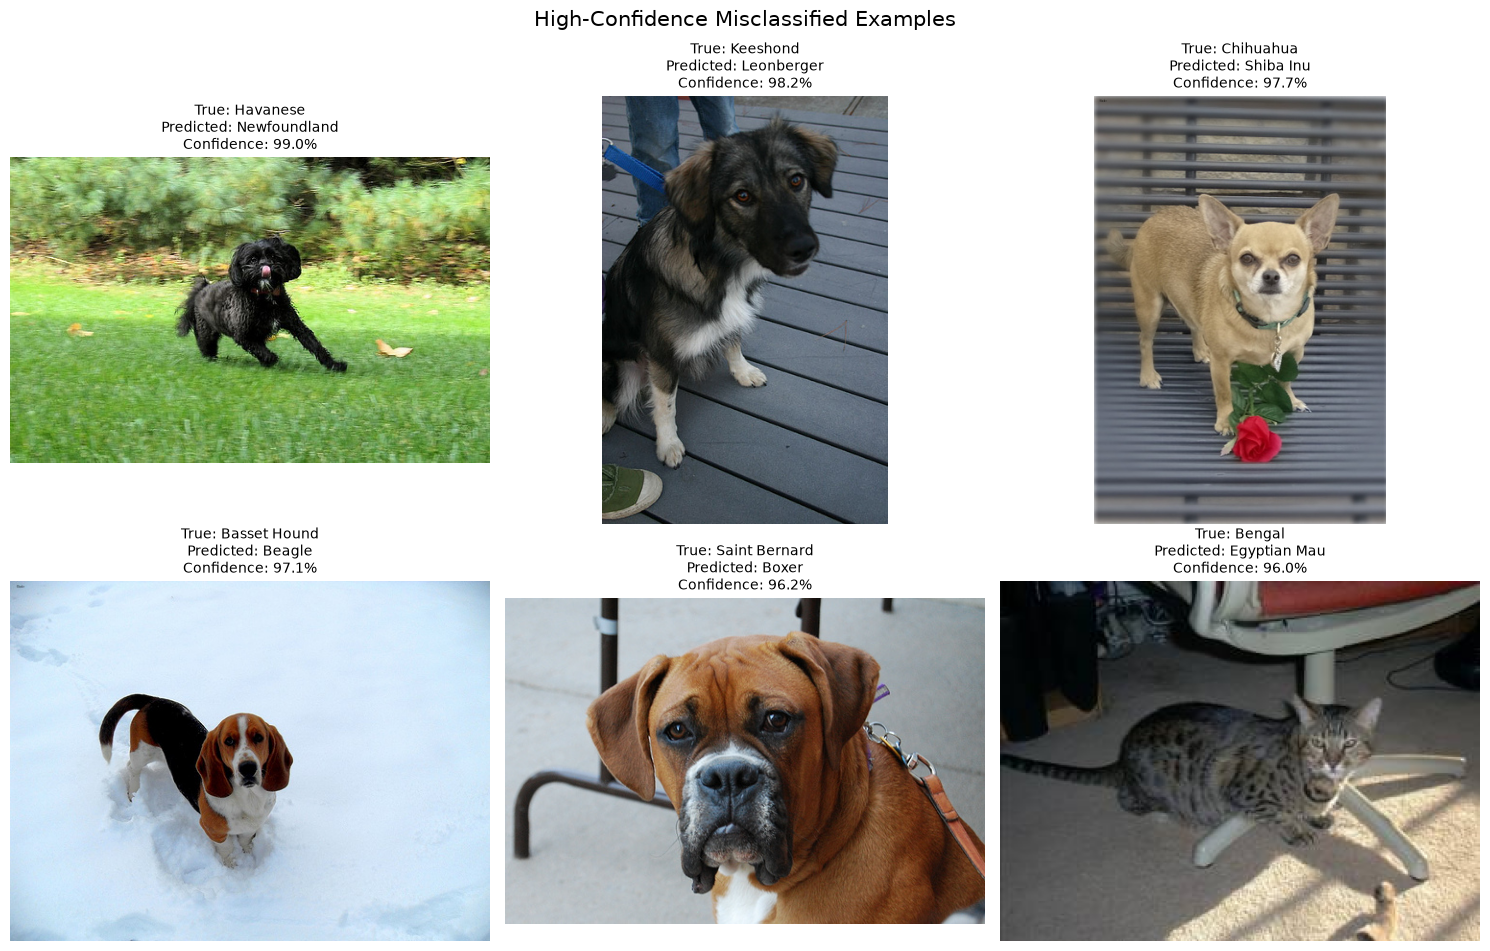

In [21]:
examples_to_display = (
    misclassified_examples.head(6)
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)

for axis, (_, example) in zip(
    axes.flat,
    examples_to_display.iterrows(),
):
    bgr_image = cv2.imread(
        example["image_path"]
    )
    rgb_image = cv2.cvtColor(
        bgr_image,
        cv2.COLOR_BGR2RGB,
    )

    axis.imshow(rgb_image)
    axis.set_title(
        "True: "
        + example["true_breed"].replace("_", " ").title()
        + "\nPredicted: "
        + example["predicted_breed"].replace("_", " ").title()
        + f"\nConfidence: {example['confidence']:.1%}",
        fontsize=10,
    )
    axis.axis("off")

plt.suptitle(
    "High-Confidence Misclassified Examples",
    fontsize=15,
)
plt.tight_layout()

plt.savefig(
    DAY4_OUTPUT_DIRECTORY /
    "misclassified_examples.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

<h3 style="color:#009E73;">Categorizing the Errors</h3>

To make error categorization reproducible, image sharpness and brightness are
measured first.

The categories are preliminary:

- **Data issue:** unusually blurred or extremely dark/bright image.
- **Model weakness:** readable image where the model confused visually similar breeds.

Human visual inspection remains important because occlusion, unusual poses, and
incorrect labels cannot always be detected using one numerical measurement.

In [22]:
def measure_image_quality(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return np.nan, np.nan

    grayscale = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY,
    )

    sharpness = cv2.Laplacian(
        grayscale,
        cv2.CV_64F,
    ).var()

    brightness = grayscale.mean()

    return sharpness, brightness


review_examples = (
    misclassified_examples.head(3).copy()
)

quality_measurements = review_examples[
    "image_path"
].apply(measure_image_quality)

review_examples["sharpness"] = [
    result[0]
    for result in quality_measurements
]

review_examples["brightness"] = [
    result[1]
    for result in quality_measurements
]


def categorize_error(row):
    if row["sharpness"] < 70:
        return "Data issue: possible blur"

    if (
        row["brightness"] < 45
        or row["brightness"] > 210
    ):
        return "Data issue: extreme lighting"

    if row["confidence"] >= 0.70:
        return (
            "Model weakness: confident confusion "
            "between similar breeds"
        )

    return (
        "Model weakness: insufficient "
        "discriminative visual features"
    )


review_examples["error_category"] = (
    review_examples.apply(
        categorize_error,
        axis=1,
    )
)

error_review_table = review_examples[
    [
        "filename",
        "true_breed",
        "predicted_breed",
        "confidence",
        "sharpness",
        "brightness",
        "error_category",
    ]
].copy()

display(error_review_table.round(3))

error_review_table.to_csv(
    DAY4_OUTPUT_DIRECTORY /
    "three_error_case_review.csv",
    index=False,
)

,filename,true_breed,predicted_breed,confidence,sharpness,brightness,error_category
0,havanese_170.jpg,havanese,newfoundland,0.990,2050.117,140.976,Model weakness: confident confusion between si...
1,keeshond_130.jpg,keeshond,leonberger,0.982,521.714,78.539,Model weakness: confident confusion between si...
2,chihuahua_21.jpg,chihuahua,shiba_inu,0.977,312.212,109.013,Model weakness: confident confusion between si...


<h2 style="color:#0072B2;">4.12 The End-to-End Prediction Pipeline</h2>

The final prediction function accepts a raw image path and performs every required
operation in one place:

1. Read the image using OpenCV.
2. Convert BGR into RGB.
3. Resize while preserving the aspect ratio.
4. Add padding to produce a 224 × 224 image.
5. Apply MobileNetV2 normalization.
6. Run the trained classifier.
7. Return the three most probable breeds.

Using the same preprocessing function during training and prediction prevents
training/serving skew.

In [23]:
def predict_pet_breed(
    raw_image_path,
    model=best_pet_breed_model,
    top_k=3,
    show_image=True,
):
    model_input = preprocess_pet_image(
        raw_image_path
    )

    probabilities = model.predict(
        np.expand_dims(model_input, axis=0),
        verbose=0,
    )[0]

    top_indices = np.argsort(
        probabilities
    )[-top_k:][::-1]

    prediction_table = pd.DataFrame({
        "rank": np.arange(1, top_k + 1),
        "breed": [
            class_names[index]
            .replace("_", " ")
            .title()
            for index in top_indices
        ],
        "probability": probabilities[
            top_indices
        ],
        "percentage": [
            f"{probabilities[index]:.2%}"
            for index in top_indices
        ],
    })

    if show_image:
        bgr_image = cv2.imread(
            str(raw_image_path)
        )
        rgb_image = cv2.cvtColor(
            bgr_image,
            cv2.COLOR_BGR2RGB,
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(rgb_image)
        plt.title(
            "Prediction: "
            + prediction_table.loc[0, "breed"]
        )
        plt.axis("off")
        plt.show()

    return prediction_table

True breed: Bengal


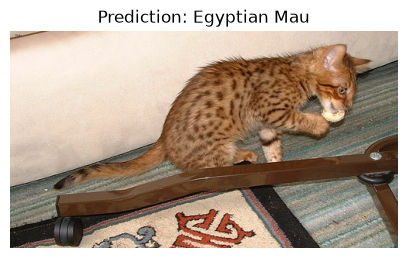

,rank,breed,probability,percentage
0,1,Egyptian Mau,0.571894,57.19%
1,2,Bengal,0.343088,34.31%
2,3,British Shorthair,0.042227,4.22%


In [24]:
demonstration_example = test_metadata.iloc[0]

print(
    "True breed:",
    demonstration_example["breed"]
    .replace("_", " ")
    .title(),
)

demonstration_prediction = predict_pet_breed(
    demonstration_example["image_path"],
    top_k=3,
)

display(demonstration_prediction)

<h2 style="color:#0072B2;">4.13 Exporting the Integrated Model</h2>

The trained model, class order, preprocessing contract, metrics, and error-analysis
tables are exported together.

The class order is essential because output position 0 must always represent the
same breed during training and deployment.

These files provide the foundation for connecting the classifier to a future web
interface without changing its preprocessing behavior.

In [25]:
import json

FINAL_MODEL_PATH = (
    DAY4_OUTPUT_DIRECTORY /
    "pet_breed_classifier.keras"
)

CLASS_NAMES_PATH = (
    DAY4_OUTPUT_DIRECTORY /
    "class_names.json"
)

PREPROCESSING_PATH = (
    DAY4_OUTPUT_DIRECTORY /
    "preprocessing_config.json"
)

best_pet_breed_model.save(
    FINAL_MODEL_PATH
)

with open(
    CLASS_NAMES_PATH,
    "w",
    encoding="utf-8",
) as class_file:
    json.dump(
        class_names,
        class_file,
        indent=2,
    )

preprocessing_config = {
    "library": "OpenCV",
    "color_input": "BGR",
    "color_model": "RGB",
    "target_width": TARGET_SIZE[0],
    "target_height": TARGET_SIZE[1],
    "resize_method": "aspect_ratio_with_padding",
    "normalization": "MobileNetV2 preprocess_input",
    "expected_range": [-1.0, 1.0],
    "number_of_classes": len(class_names),
}

with open(
    PREPROCESSING_PATH,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        preprocessing_config,
        configuration_file,
        indent=2,
    )

print("Export completed:")
print("-", FINAL_MODEL_PATH)
print("-", CLASS_NAMES_PATH)
print("-", PREPROCESSING_PATH)

Export completed:
- outputs/week8_day4/pet_breed_classifier.keras
- outputs/week8_day4/class_names.json
- outputs/week8_day4/preprocessing_config.json


<h2 style="color:#0072B2;">Final Results Summary</h2>

The best model achieved:

- **Validation accuracy:** 90.07%
- **Test accuracy:** 89.00%
- **Test Top-3 accuracy:** 98.38%
- **Correct test predictions:** 987 out of 1,109
- **Misclassified images:** 122
- **Macro F1-score:** 88.96%

The weakest recall appeared in visually similar categories such as Bengal,
American Pit Bull Terrier, and Staffordshire Bull Terrier.

The small difference between validation and test accuracy indicates good
generalization. The Top-3 result also shows that the correct breed was usually
among the model's strongest candidates, even when the Top-1 prediction was wrong.

<h2 style="color:#0072B2;">Day 4 Conclusion</h2>

The Day 3 preprocessing operations and the trained MobileNetV2 classifier were
combined into one consistent end-to-end system.

The completed workflow now:

- Accepts raw image paths.
- Applies identical training and prediction preprocessing.
- Produces probabilities for 37 pet breeds.
- Reports Top-1 and Top-3 accuracy.
- Uses a normalized confusion matrix to locate breed confusion.
- Inspects and categorizes individual prediction errors.
- Exports the model and its preprocessing contract for future web integration.

The model is now more than an isolated notebook experiment: it is a reproducible
prediction pipeline ready for deployment.